In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [11]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [12]:
df['Price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [15]:
X=df.drop('Price',axis=1)

In [16]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [17]:
y=df['Price']

In [18]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lm = LinearRegression()

In [23]:
model = lm.fit(X_train, y_train)

In [26]:
ytrain_pred = lm.predict(X_train)

In [41]:
ytest_pred = lm.predict(X_test)

In [43]:
df=pd.DataFrame(ytrain_pred, y_train)

In [44]:
df=pd.DataFrame(ytest_pred, y_test)

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
mse = mean_squared_error(y_test, ytest_pred)

In [47]:
mse = mean_squared_error(ytrain_pred, y_train)

In [48]:
print(mse)

0.5179331255246699


In [49]:
mse = mean_squared_error(ytest_pred, y_test)

In [50]:
print(mse)

0.5558915986952442


In [65]:
import matplotlib.pyplot as plt

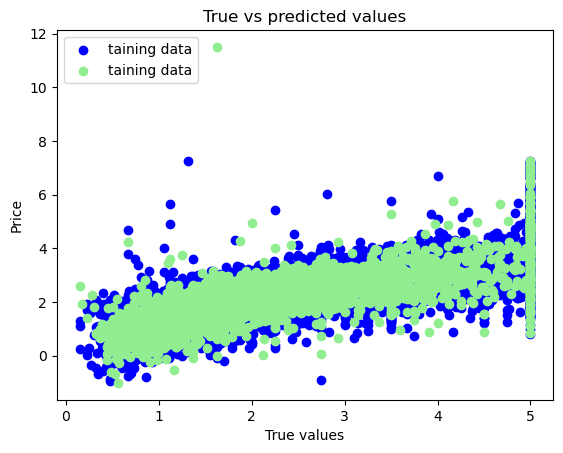

In [84]:
plt.scatter(y_train, ytrain_pred, c='blue', marker='o', label='taining data')
plt.scatter(y_test, ytest_pred, c='lightgreen', marker='o', label='taining data')
plt.xlabel('True values')
plt.ylabel('Price')
plt.title("True vs predicted values")
plt.legend(loc='upper left')
plt.plot()
plt.show()